In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [4]:
data = pd.read_csv('../data/interim/Crash_Reporting_-_Drivers_Data_cleaned.csv')
df = data.copy()

In [5]:
col_list = []
for col in df:
    col_list.append(col)
sorted(col_list)    

['ACRS Report Type',
 'Agency Name',
 'Collision Type',
 'Collision Type Clean',
 'Crash Dayofweek',
 'Crash Dayofweek Clean',
 'Crash Hour',
 'Crash Location Type',
 'Crash Month',
 'Crash Month Clean',
 'Crash Season Clean',
 'Cross Road Category Clean',
 'Cross-Street Name',
 'Driver At Fault',
 'Driver Distracted By',
 'Driver Distracted By Clean',
 'Driver Substance Abuse',
 'Driver Substance Abuse Clean',
 'Driverless Vehicle',
 'Drivers License State',
 'Drivers License State clean',
 'Injury Severity',
 'Is Weekend',
 'Latitude',
 'Light',
 'Light Clean',
 'Location Cluster Clean',
 'Longitude',
 'Municipality',
 'Non-Motorist Substance Abuse',
 'Non-Motorist Substance Abuse Clean',
 'Off-Road Description',
 'Off-Road Description Clean',
 'Parked Vehicle',
 'Related Non-Motorist',
 'Related Non-Motorist Clean',
 'Road Category Clean',
 'Road Name',
 'Route Type',
 'Route Type Clean',
 'Speed Limit',
 'Surface Condition',
 'Surface Condition Clean',
 'Time Of Day Clean',
 'Traff

In [6]:
uncleaned_cols = [
    'Collision Type',
    'Crash Dayofweek',
    'Cross-Street Name',
    'Driver Distracted By',
    'Driver Substance Abuse',
    'Drivers License State',
    'Light',
    'Non-Motorist Substance Abuse',
    'Off-Road Description',
    'Related Non-Motorist',
    'Road Name',
    'Route Type',
    'Surface Condition',
    'Traffic Control',
    'Vehicle Body Type',
    'Vehicle Damage Extent',
    'Vehicle First Impact Location',
    'Vehicle Going Dir',
    'Vehicle Movement',
    'Vehicle Year',
    'Weather',
    'Crash Month',
]
df_model = df.copy()
df_model = df_model.drop(columns=uncleaned_cols)

df_model.shape

(207766, 39)

In [7]:
Post_event_col = ['Driver At Fault','Vehicle Damage Extent Clean',]
messy_col = ['ACRS Report Type','Agency Name','Latitude','Longitude',]

df_model = df_model.drop(columns=Post_event_col)
df_model = df_model.drop(columns=messy_col)

In [8]:
col_list = []
for col in df_model:
    col_list.append(col)
sorted(col_list) 

['Collision Type Clean',
 'Crash Dayofweek Clean',
 'Crash Hour',
 'Crash Location Type',
 'Crash Month Clean',
 'Crash Season Clean',
 'Cross Road Category Clean',
 'Driver Distracted By Clean',
 'Driver Substance Abuse Clean',
 'Driverless Vehicle',
 'Drivers License State clean',
 'Injury Severity',
 'Is Weekend',
 'Light Clean',
 'Location Cluster Clean',
 'Municipality',
 'Non-Motorist Substance Abuse Clean',
 'Off-Road Description Clean',
 'Parked Vehicle',
 'Related Non-Motorist Clean',
 'Road Category Clean',
 'Route Type Clean',
 'Speed Limit',
 'Surface Condition Clean',
 'Time Of Day Clean',
 'Traffic Control Clean',
 'Vehicle Age',
 'Vehicle Body Type Clean',
 'Vehicle First Impact Location Clean',
 'Vehicle Going Dir Clean',
 'Vehicle Movement Clean',
 'Vehicle Year Clean',
 'Weather Clean']

In [9]:
low_cardinality_cols = [col for col in df_model.columns if df_model[col].nunique() > 30]

for col in low_cardinality_cols:
    print("-------------------------------------------")
    print(f"Name : {col}")
    print(f'{df_model[col].value_counts(dropna=False)}')
    print("-------------------------------------------")

-------------------------------------------
Name : Vehicle Year Clean
Vehicle Year Clean
2015.0    14031
2014.0    13602
2016.0    13577
2011.0    13057
2013.0    12967
          ...  
1976.0        2
1960.0        1
1961.0        1
1959.0        1
1957.0        1
Name: count, Length: 68, dtype: int64
-------------------------------------------
-------------------------------------------
Name : Vehicle Age
Vehicle Age
11.0    14031
12.0    13602
10.0    13577
15.0    13057
13.0    12967
        ...  
50.0        2
66.0        1
65.0        1
67.0        1
69.0        1
Name: count, Length: 68, dtype: int64
-------------------------------------------


['Route Type Clean']

# Feature Engieering

##### Muncipalty

In [10]:
df_model["Is_Incorporated"] = df_model["Municipality"].apply(
    lambda x: 0 if x == "UNINCORPORATED" else 1
)

df_model["Is_Incorporated"].value_counts()
#Done

Is_Incorporated
0    188640
1     19126
Name: count, dtype: int64

In [11]:
df_model = df_model.drop(columns=["Municipality"])

In [12]:
df_model["Parked Vehicle"] = df_model["Parked Vehicle"].map({
    "NO": 0,
    "YES": 1
})
#Done

In [13]:
df_model["Driverless Vehicle"] = df_model["Driverless Vehicle"].map({
    "NO": 0,
    "UNKNOWN": 1
})
#Done

In [14]:
df_model["Collision Type Clean"] = df_model["Collision Type Clean"].replace(
    {"UNKNOWN": "OTHER"}
)
#done

In [15]:
df_model["Collision Type Clean"].value_counts()

Collision Type Clean
REAR_END          68539
ANGLE             41265
OTHER             32674
SIDESWIPE         25748
SINGLE_VEHICLE    20054
HEAD_ON           19486
Name: count, dtype: int64

In [16]:
df_model["Weather Clean"] = df_model["Weather Clean"].replace({
    "WIND": "OTHER",
    "DUST": "OTHER"
})

In [17]:
df_model["Surface Condition Clean"] = df_model["Surface Condition Clean"].replace({
    "LOOSE_SURFACE": "OTHER"
})
#Done

In [18]:
df_model["Light Clean"] = df_model["Light Clean"].replace({
    "OTHER": "UNKNOWN"
})
#Done

In [19]:
df_model["Traffic Control Clean"] = df_model["Traffic Control Clean"].replace({
    "FLASHING_SIGNAL": "OTHER",
    "SCHOOL_ZONE": "OTHER",
    "RAILROAD": "OTHER"
})

In [20]:
df_model["Driver Substance Abuse Clean"] = df_model["Driver Substance Abuse Clean"].replace({
    "MEDICATION": "DRUG",
    "COMBINED": "DRUG",
    "OTHER": "DRUG"
})

In [21]:
df_model["Non-Motorist Substance Abuse Clean"] = df_model["Non-Motorist Substance Abuse Clean"].apply(
    lambda x: 0 if x in ["NOT_APPLICABLE", "NONE", "UNKNOWN"] else 1
)
#Done

In [22]:
df_model["Driver Distracted By Clean"] = df_model["Driver Distracted By Clean"].replace({
    "DEVICE_RELATED": "DISTRACTION",
    "PHONE_RELATED": "DISTRACTION",
    "IN_VEHICLE_DISTRACTION": "DISTRACTION",
    "OTHER": "DISTRACTION"
})
#done

In [23]:
df_model["Vehicle Body Type Clean"] = df_model["Vehicle Body Type Clean"].replace({
    "INDUSTRIAL_FARM": "OTHER",
    "OFF_ROAD": "OTHER"
})

In [24]:
df_model["Vehicle Movement Clean"] = df_model["Vehicle Movement Clean"].replace({
    "DRIVERLESS": "UNKNOWN"
})

In [25]:
df_model["Vehicle Going Dir Clean"] = df_model["Vehicle Going Dir Clean"].replace({
    "NOT_ON_ROAD": "UNKNOWN"
})

In [26]:
df_model["Related Non-Motorist Clean"] = df_model["Related Non-Motorist Clean"].apply(
    lambda x: 0 if x == "NONE_OR_UNKNOWN" else 1
)
#Done

In [27]:
df_model = df_model.drop(columns=['Crash Hour','Crash Month Clean','Off-Road Description Clean','Vehicle Year Clean'])
#Off-Road Description drooped because 91% was unknown

In [28]:
df_model['Drivers License State clean'] = df_model['Drivers License State clean'].replace({
    "INTERNATIONAL": "OTHER",
    "US_TERRITORY": "OTHER"
})
#Done

In [29]:
df_model["Location Cluster Clean"] = df_model["Location Cluster Clean"].astype("category")

In [30]:
bins = [0, 10, 20, 30, 40, np.inf]
labels = ['0-10', '10-20', '20-30', '30-40','40+']
df_model['Vehicle Age'] = pd.cut(df_model['Vehicle Age'], bins=bins, labels=labels, right=True,include_lowest=True)

bins = [0, 10, 20, 30, 40, np.inf]
labels = ['0-10', '10-20', '20-30', '30-40', '40+']
df_model['Speed Limit'] = pd.cut(df_model['Speed Limit'], bins=bins, labels=labels, right=True)


In [31]:
for col in df_model:
    print('----------------------')
    print(f'{col}')
    print(f"{df_model[col].unique()}")
    print('----------------------')

----------------------
Injury Severity
['NO APPARENT INJURY' 'POSSIBLE INJURY' 'SUSPECTED MINOR INJURY'
 'SUSPECTED SERIOUS INJURY' 'FATAL INJURY']
----------------------
----------------------
Speed Limit
['30-40', '20-30', '40+', '0-10', '10-20']
Categories (5, object): ['0-10' < '10-20' < '20-30' < '30-40' < '40+']
----------------------
----------------------
Driverless Vehicle
[0 1]
----------------------
----------------------
Parked Vehicle
[0 1]
----------------------
----------------------
Route Type Clean
['Highway/Main' 'Gov/Private/Special' 'Local/Municipal' 'Other/Unknown']
----------------------
----------------------
Collision Type Clean
['REAR_END' 'SIDESWIPE' 'SINGLE_VEHICLE' 'HEAD_ON' 'ANGLE' 'OTHER']
----------------------
----------------------
Weather Clean
['CLEAR' 'RAIN' 'CLOUDY' 'OTHER' 'FOG' 'WINTER' 'UNKNOWN']
----------------------
----------------------
Surface Condition Clean
['DRY' 'WET' 'UNKNOWN' 'OTHER' 'WINTER']
----------------------
------------------

In [32]:
df_model['Vehicle First Impact Location Clean'].value_counts(dropna=False)

Vehicle First Impact Location Clean
FRONT            132236
REAR              50400
REAR_SIDE          9700
SIDE               9157
UNKNOWN            4176
ROLLOVER_TOP       1260
NON_COLLISION       837
Name: count, dtype: int64

In [33]:
df_model["target"] = df_model["Injury Severity"].apply(
    lambda x: 0 if x == "NO APPARENT INJURY" else 1
)

df_model.drop(columns=["Injury Severity"], inplace=True)

In [34]:
df_model.to_csv('../data/processed/Crash_Reporting_-_Drivers_Data_model.csv',index=False)

In [35]:
X = df_model.drop("target", axis=1)
y = df_model["target"]

In [36]:
X = pd.get_dummies(X, drop_first=True)

In [37]:
X = X.astype(int)

In [35]:
X_cols = [col for col in X.columns]

for col in X_cols:
    print("-------------------------------------------")
    print(f"Name : {col}")
    print(f'{X[col].value_counts(dropna=False)}')
    print("-------------------------------------------")

-------------------------------------------
Name : Driverless Vehicle
Driverless Vehicle
0    207021
1       745
Name: count, dtype: int64
-------------------------------------------
-------------------------------------------
Name : Parked Vehicle
Parked Vehicle
0    204360
1      3406
Name: count, dtype: int64
-------------------------------------------
-------------------------------------------
Name : Non-Motorist Substance Abuse Clean
Non-Motorist Substance Abuse Clean
0    207546
1       220
Name: count, dtype: int64
-------------------------------------------
-------------------------------------------
Name : Related Non-Motorist Clean
Related Non-Motorist Clean
0    201065
1      6701
Name: count, dtype: int64
-------------------------------------------
-------------------------------------------
Name : Is Weekend
Is Weekend
0    160102
1     47664
Name: count, dtype: int64
-------------------------------------------
-------------------------------------------
Name : Crash Loca

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
y_train.value_counts(normalize=True)

target
0    0.821728
1    0.178272
Name: proportion, dtype: float64

In [38]:
y_test.value_counts(normalize=True)

target
0    0.821726
1    0.178274
Name: proportion, dtype: float64

### Using Random Forest

In [39]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=10,
    min_samples_split=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
y_prob = rf.predict_proba(X_test)[:, 1]

In [41]:
threshold = 0.48
y_pred_new = (y_prob >= threshold).astype(int)

In [42]:
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[15272 18874]
 [ 1243  6165]]
              precision    recall  f1-score   support

           0       0.92      0.45      0.60     34146
           1       0.25      0.83      0.38      7408

    accuracy                           0.52     41554
   macro avg       0.59      0.64      0.49     41554
weighted avg       0.80      0.52      0.56     41554



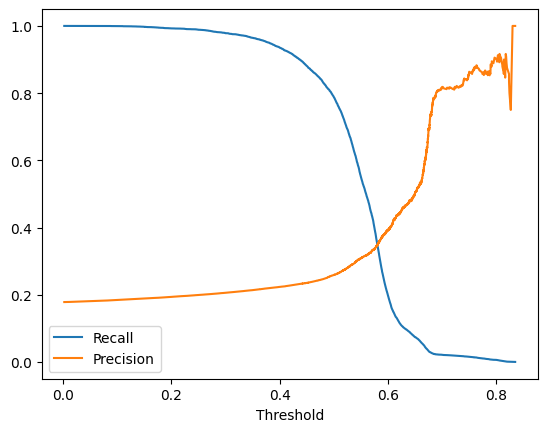

In [43]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, precision[:-1], label="Precision")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [44]:
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = np.nan_to_num(f1_scores)  # remove NaNs

best_index = np.argmax(f1_scores[:-1])  # ignore last value
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)

Best threshold: 0.5307831584365497


In [45]:
y_prob_train = rf.predict_proba(X_train)[:, 1]
# 2. Apply your 0.198 threshold to Training set
y_pred_train_custom = (y_prob_train >= threshold).astype(int)

In [46]:
train_acc = accuracy_score(y_train, y_pred_train_custom)
test_acc = accuracy_score(y_test, y_pred_new)
print(f"Custom Train Accuracy: {train_acc:.2%}")
print(f"Custom Test Accuracy: {test_acc:.2%}")

Custom Train Accuracy: 52.44%
Custom Test Accuracy: 51.59%


In [47]:
print(classification_report(y_train, y_pred_train_custom))

              precision    recall  f1-score   support

           0       0.94      0.45      0.61    136581
           1       0.25      0.86      0.39     29631

    accuracy                           0.52    166212
   macro avg       0.60      0.66      0.50    166212
weighted avg       0.82      0.52      0.57    166212



### Using XGBOOST

In [48]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4.6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [49]:
probs = xgb.predict_proba(X_test)[:,1]

In [50]:
threshold_xgb = 0.48
y_pred_xgb = (probs > threshold_xgb).astype(int)

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[18864 15282]
 [ 1640  5768]]
              precision    recall  f1-score   support

           0       0.92      0.55      0.69     34146
           1       0.27      0.78      0.41      7408

    accuracy                           0.59     41554
   macro avg       0.60      0.67      0.55     41554
weighted avg       0.80      0.59      0.64     41554



In [51]:
y_prob_train = xgb.predict_proba(X_train)[:, 1]
y_pred_train_custom = (y_prob_train >= threshold_xgb).astype(int)

In [52]:
print(classification_report(y_train, y_pred_train_custom))

              precision    recall  f1-score   support

           0       0.93      0.56      0.70    136581
           1       0.28      0.80      0.42     29631

    accuracy                           0.60    166212
   macro avg       0.61      0.68      0.56    166212
weighted avg       0.81      0.60      0.65    166212



In [53]:
train_acc = accuracy_score(y_train, y_pred_train_custom)
test_acc = accuracy_score(y_test, y_pred_xgb)
print(f"Custom Train Accuracy: {train_acc:.2%}")
print(f"Custom Test Accuracy: {test_acc:.2%}")

Custom Train Accuracy: 60.11%
Custom Test Accuracy: 59.28%


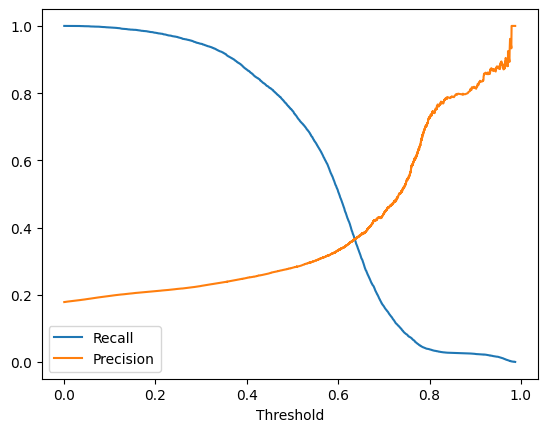

In [54]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, precision[:-1], label="Precision")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [55]:
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = np.nan_to_num(f1_scores)  # remove NaNs

best_index = np.argmax(f1_scores[:-1])  # ignore last value
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)

Best threshold: 0.56279415
